# 01 — Exploratory Data Analysis

Understand the raw spam.csv dataset before any modelling.

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import config

plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

## 1. Load raw data

In [2]:
df = pd.read_csv(config.DATASET_PATH, encoding='latin-1',
                 usecols=[0,1], names=[config.LABEL_COL, config.TEXT_COL], header=0)
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)
print(f"Shape: {df.shape}")
df.head(10)

Shape: (5169, 2)


,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
5,spam,FreeMsg Hey there darling it's been 3 week's n...
6,ham,Even my brother is not like to speak with me. ...
7,ham,As per your request 'Melle Melle (Oru Minnamin...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...


## 2. Class distribution

v1
ham     4516
spam     653
Name: count, dtype: int64


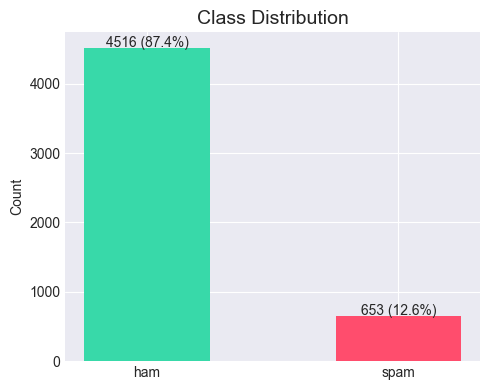

In [3]:
counts = df[config.LABEL_COL].value_counts()
print(counts)
fig, ax = plt.subplots(figsize=(5,4))
ax.bar(counts.index, counts.values, color=['#38d9a9','#ff4d6d'], edgecolor='none', width=.5)
ax.set_title('Class Distribution', fontsize=14)
ax.set_ylabel('Count')
for i,(v,c) in enumerate(zip(counts.values, counts.index)):
    ax.text(i, v+10, f'{v} ({v/len(df)*100:.1f}%)', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('../saved_plots/class_distribution.png', dpi=150)
plt.show()

## 3. Message length analysis

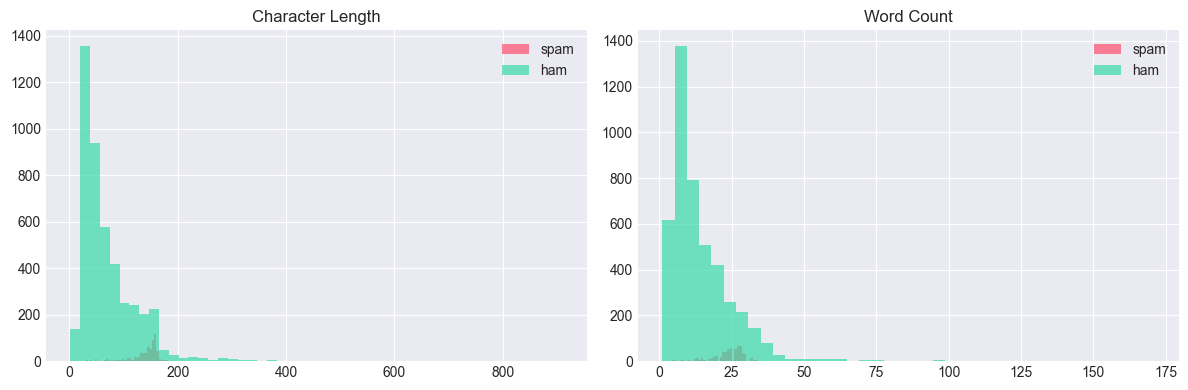

v1                        ham        spam
msg_len    count  4516.000000  653.000000
           mean     70.459256  137.891271
           std      56.358207   30.137753
           min       2.000000   13.000000
           25%      34.000000  132.000000
           50%      52.000000  149.000000
           75%      90.000000  157.000000
           max     910.000000  224.000000
word_count count  4516.000000  653.000000
           mean     14.134632   23.681470
           std      11.116240    5.967672
           min       1.000000    2.000000
           25%       7.000000   22.000000
           50%      11.000000   25.000000
           75%      18.000000   28.000000
           max     171.000000   35.000000


In [4]:
df['msg_len'] = df[config.TEXT_COL].str.len()
df['word_count'] = df[config.TEXT_COL].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for label, color in [('spam','#ff4d6d'),('ham','#38d9a9')]:
    sub = df[df[config.LABEL_COL]==label]
    axes[0].hist(sub['msg_len'], bins=50, alpha=.7, label=label, color=color)
    axes[1].hist(sub['word_count'], bins=40, alpha=.7, label=label, color=color)

for ax, title in zip(axes, ['Character Length','Word Count']):
    ax.set_title(title); ax.legend()
plt.tight_layout()
plt.savefig('../saved_plots/length_distribution.png', dpi=150)
plt.show()

print(df.groupby(config.LABEL_COL)[['msg_len','word_count']].describe().T)

## 4. Top words (spam vs ham)

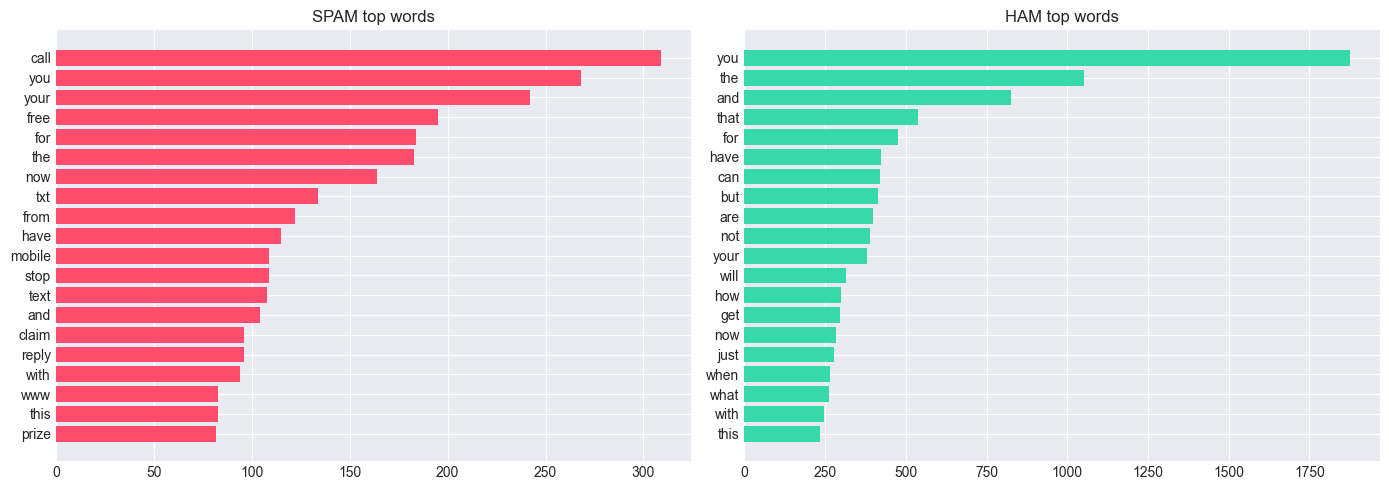

In [5]:
from collections import Counter
import re

def top_words(df, label, n=20):
    texts = ' '.join(df[df[config.LABEL_COL]==label][config.TEXT_COL].str.lower())
    words = re.findall(r'\b[a-z]{3,}\b', texts)
    return Counter(words).most_common(n)

spam_words = top_words(df, 'spam')
ham_words  = top_words(df, 'ham')

fig, axes = plt.subplots(1,2,figsize=(14,5))
for ax, words, color, title in zip(axes,
        [spam_words, ham_words], ['#ff4d6d','#38d9a9'], ['SPAM top words','HAM top words']):
    wds, cnts = zip(*words)
    ax.barh(wds[::-1], cnts[::-1], color=color, edgecolor='none')
    ax.set_title(title)
plt.tight_layout()
plt.savefig('../saved_plots/top_words.png', dpi=150)
plt.show()